In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/TUANDROMD.csv'
# Load the dataset
df = pd.read_csv(file_path, header=0)
# First rows
print("\n First rows:")
print(df.head().to_string())


 Prime righe:
   ACCESS_ALL_DOWNLOADS  ACCESS_CACHE_FILESYSTEM  ACCESS_CHECKIN_PROPERTIES  ACCESS_COARSE_LOCATION  ACCESS_COARSE_UPDATES  ACCESS_FINE_LOCATION  ACCESS_LOCATION_EXTRA_COMMANDS  ACCESS_MOCK_LOCATION  ACCESS_MTK_MMHW  ACCESS_NETWORK_STATE  ACCESS_PROVIDER  ACCESS_SERVICE  ACCESS_SHARED_DATA  ACCESS_SUPERUSER  ACCESS_SURFACE_FLINGER  ACCESS_WIFI_STATE  activityCalled  ACTIVITY_RECOGNITION  ACCOUNT_MANAGER  ADD_VOICEMAIL  ANT  ANT_ADMIN  AUTHENTICATE_ACCOUNTS  AUTORUN_MANAGER_LICENSE_MANAGER  AUTORUN_MANAGER_LICENSE_SERVICE(.autorun)  BATTERY_STATS  BILLING  BIND_ACCESSIBILITY_SERVICE  BIND_APPWIDGET  BIND_CARRIER_MESSAGING_SERVICE  BIND_DEVICE_ADMIN  BIND_DREAM_SERVICE  BIND_GET_INSTALL_REFERRER_SERVICE  BIND_INPUT_METHOD  BIND_NFC_SERVICE  BIND_0TIFICATION_LISTENER_SERVICE  BIND_PRINT_SERVICE  BIND_REMOTEVIEWS  BIND_TEXT_SERVICE  BIND_TV_INPUT  BIND_VOICE_INTERACTION  BIND_VPN_SERVICE  BIND_WALLPAPER  BLUETOOTH  BLUETOOTH_ADMIN  BLUETOOTH_PRIVILEGED  BODY_SENSORS  BRICK  

Numero di righe: 4465
Numero di colonne: 242
Label: Label

 Numero totale di nan: 242
                           Missing Values  % Missing
ACCESS_ALL_DOWNLOADS                    1   0.022396
ACCESS_CACHE_FILESYSTEM                 1   0.022396
ACCESS_CHECKIN_PROPERTIES               1   0.022396
ACCESS_COARSE_LOCATION                  1   0.022396
ACCESS_COARSE_UPDATES                   1   0.022396


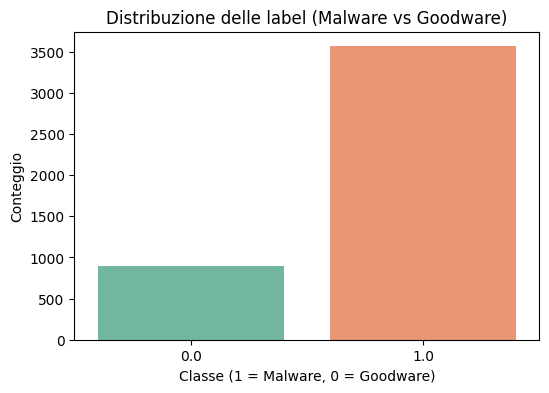


 Distribuzione percentuale delle label:
Label
1.0    79.861111
0.0    20.138889
Name: proportion, dtype: float64

 Prime 10 feature più correlate con la classe:
RECEIVE_BOOT_COMPLETED       0.760417
GET_TASKS                    0.563214
WAKE_LOCK                    0.472105
KILL_BACKGROUND_PROCESSES    0.438312
SYSTEM_ALERT_WINDOW          0.281178
DISABLE_KEYGUARD             0.257189
READ_PHONE_STATE             0.182915
RECEIVE_SMS                  0.177635
SEND_SMS                     0.172554
READ_SMS                     0.123966
Name: Label, dtype: float64

 Numero di feature con varianza nulla: 42
Esempi di feature costanti:
ACCESS_PROVIDER                              0.0
ACCESS_SHARED_DATA                           0.0
ACCESS_SERVICE                               0.0
AUTORUN_MANAGER_LICENSE_MANAGER              0.0
ANT                                          0.0
ANT_ADMIN                                    0.0
ACTIVITY_RECOGNITION                         0.0
activityCalled  

In [ ]:
# Define features and label
target_col = "Label"
feat_cols = [c for c in df.columns if c != target_col]

# Dataset structure
n_rows, n_cols = df.shape
print("Number of rows:", n_rows)
print("Number of columns:", n_cols)
print("Label:", target_col)

# Count and percentage of NaN for each column
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    '% Missing': missing_percent
}).sort_values(by='% Missing', ascending=False)

print("\n Total number of nans:", len(missing_values))
print(missing_summary.head())

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=df, palette='Set2')
plt.title("Label distribution (Malware vs Goodware)")
plt.xlabel("Class (1 = Malware, 0 = Goodware)")
plt.ylabel("Count")
plt.show()

# Percentage of classes
label_distribution = df['Label'].value_counts(normalize=True) * 100
print("\n Percentage distribution of labels:")
print(label_distribution)

# Feature correlation (Pearson, -1;1) with the target variable
corr = df.corr()['Label'].drop('Label').sort_values(ascending=False)
print("\n Top 10 features most correlated with the class:")
print(corr.head(10))

# Variance analysis per feature
feature_variance = df.var().sort_values(ascending=True)
low_variance = feature_variance[feature_variance == 0]
print(f"\n Number of features with zero variance: {len(low_variance)}")
if len(low_variance) > 0:
    print("Examples of constant features:")
    print(low_variance)

In [ ]:
# Replace NaN with 0
df = df.fillna(0)
print("NaN replaced successfully!")

# Verify replacement operation
print("Number of NaN:", df.isna().sum().sum())

# Identify features with zero variance
features_zero_variance = df.var()[df.var() == 0].index.tolist()

# Remove features with zero variance from the DataFrame
df_cleaned = df.drop(columns=features_zero_variance)

# Print the count of removed features
print(f"Number of features removed due to zero variance: {len(features_zero_variance)}")
print(f"New number of columns in the DataFrame: {df_cleaned.shape[1]}")

df = df_cleaned

display(df.head())

NaN sostituiti con successo!
Numero di NaN: 0
Numero di feature rimosse con varianza nulla: 42
Nuovo numero di colonne nel DataFrame: 200


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


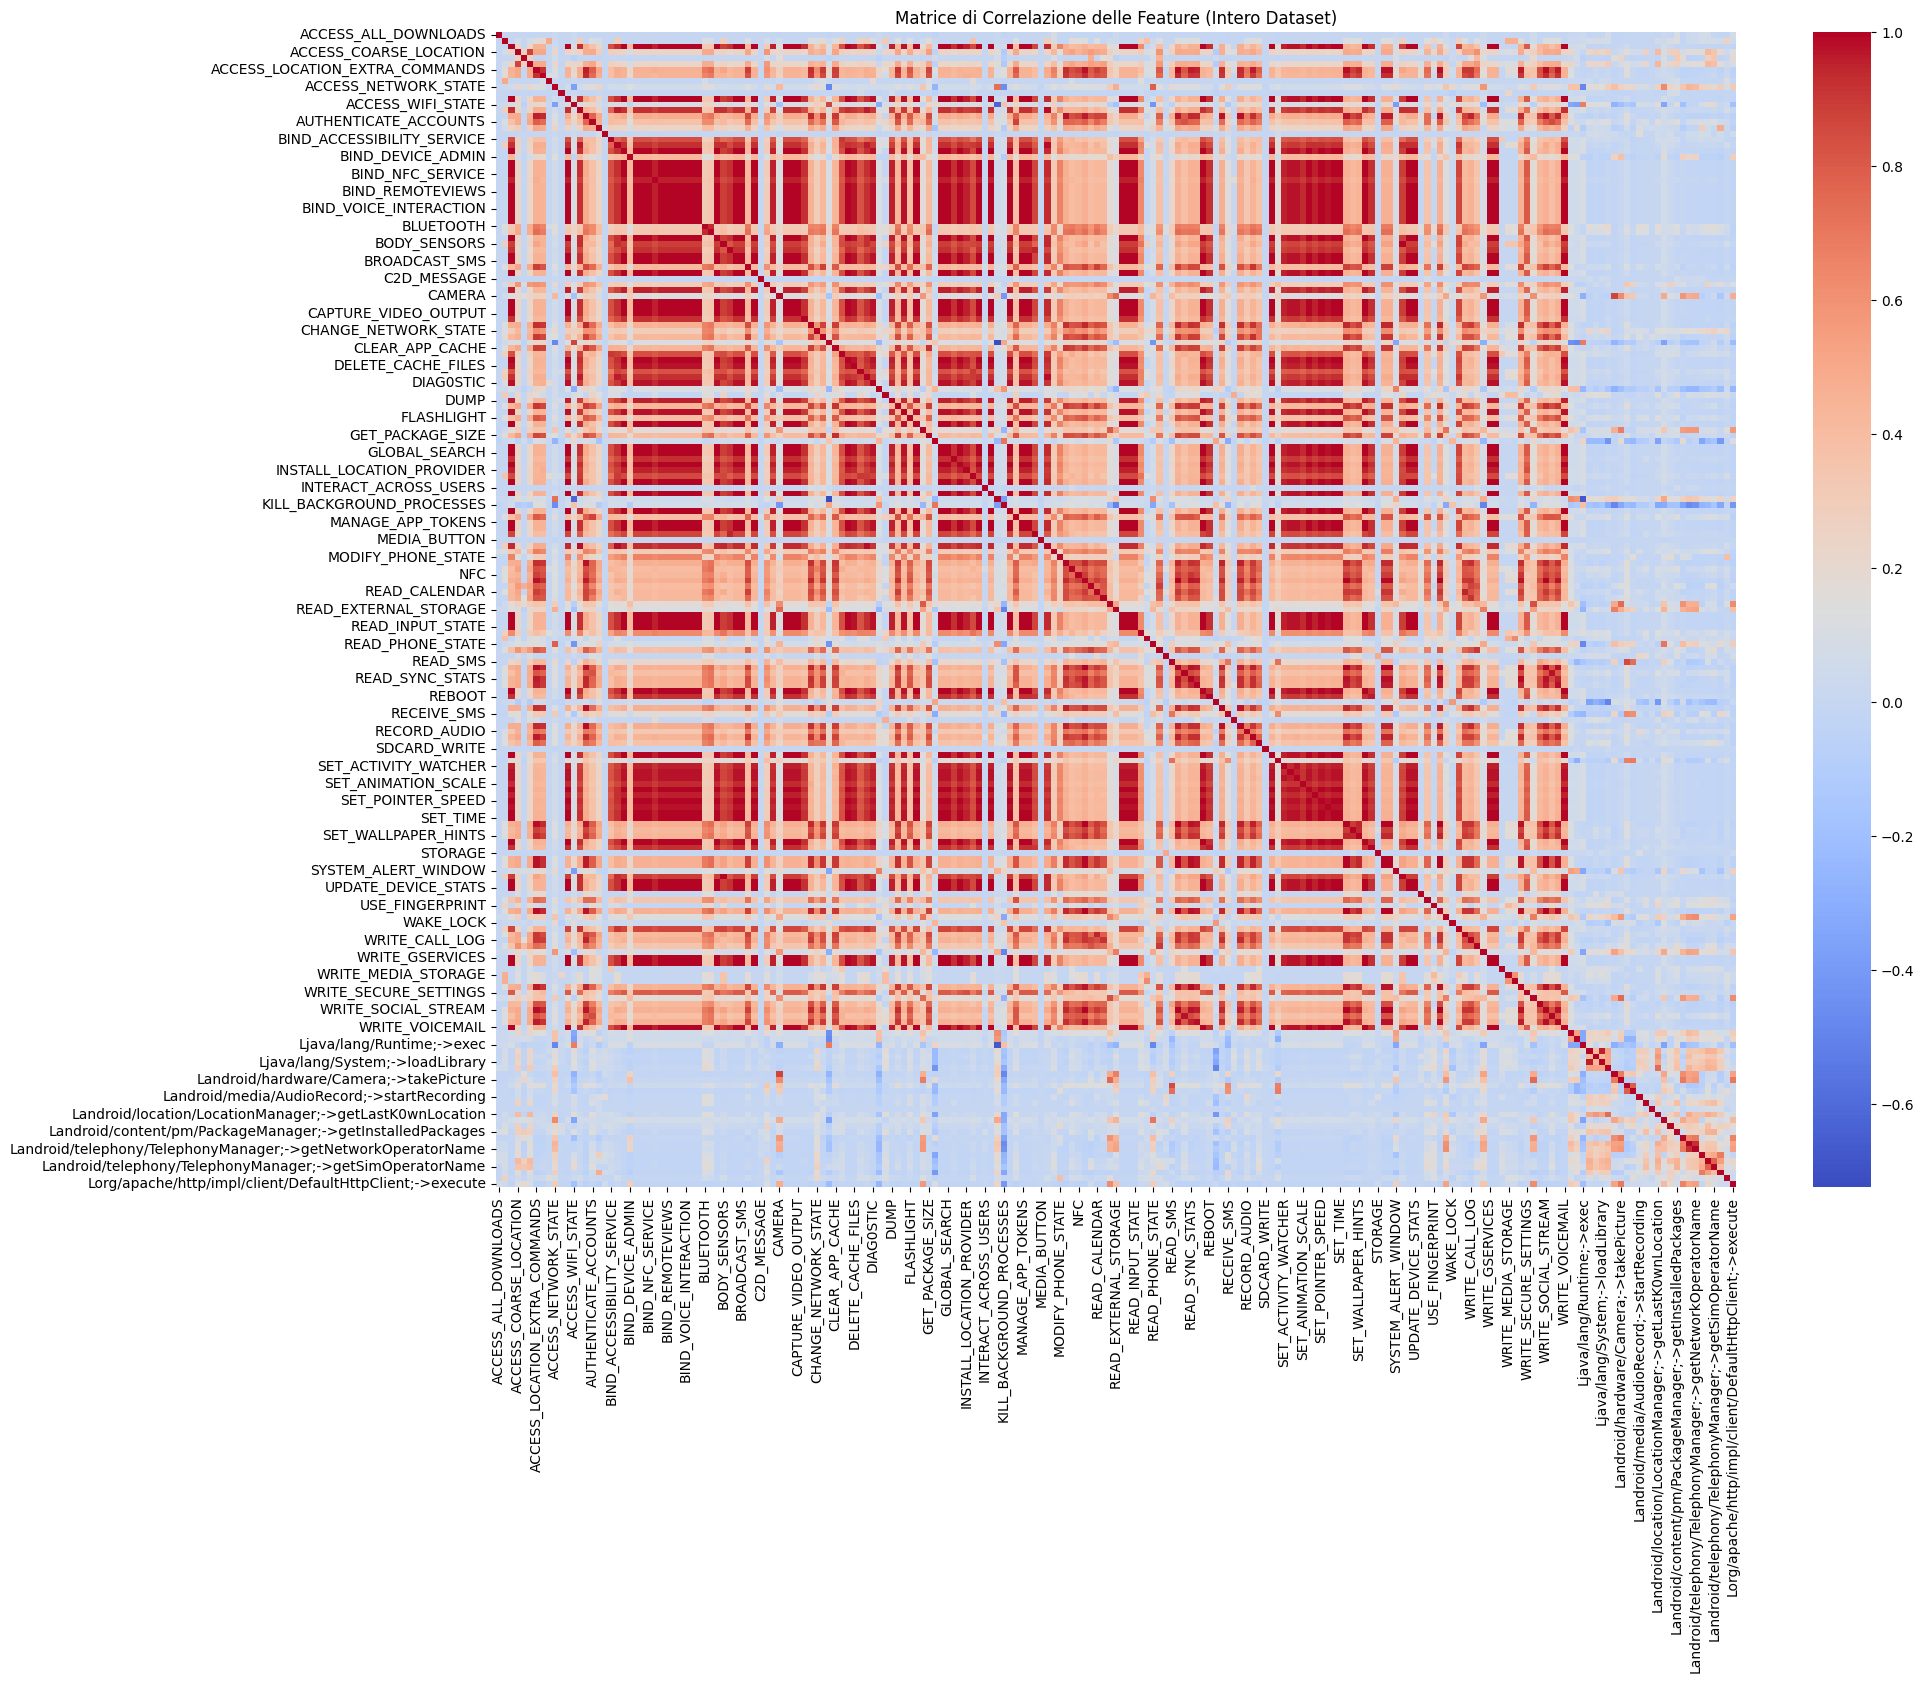


Coppie di feature con correlazione assoluta > 0.8:
WRITE_SOCIAL_STREAM  PERSISTENT_ACTIVITY    0.994873
USE_SIP              PERSISTENT_ACTIVITY    0.994873
SET_TIME_ZONE        PERSISTENT_ACTIVITY    0.994873
PERSISTENT_ACTIVITY  WRITE_SOCIAL_STREAM    0.994873
                     READ_SOCIAL_STREAM     0.994873
dtype: float64


In [ ]:
# Calculate the correlation matrix on the entire dataset
correlation_matrix = df.drop('Label', axis=1).corr()

# Plot the correlation matrix
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # annot=False to avoid overcrowding with values
plt.title('Feature Correlation Matrix (Entire Dataset)')
plt.show()

# Identify high correlations
# Find pairs of features with absolute correlation > 0.8
stacked_corr = correlation_matrix.stack()
high_corr = stacked_corr[(abs(stacked_corr) > 0.8) & (stacked_corr != 1.0)]

print("\nPairs of features with absolute correlation > 0.8:")
print(high_corr.sort_values(ascending=False).head())

In [ ]:
# Identify highly correlated features (threshold > 0.8)
# We use an iterative approach to identify one of the features to remove in each pair
correlation_threshold = 0.8
to_drop_iterative = set()
correlation_matrix_abs = correlation_matrix.abs()

# Iterate through all pairs of features in the correlation matrix
for i in range(len(correlation_matrix_abs.columns)):
    for j in range(i + 1, len(correlation_matrix_abs.columns)):
        feature1 = correlation_matrix_abs.columns[i]
        feature2 = correlation_matrix_abs.columns[j]

        # Check if the absolute correlation between the two features is greater than the threshold
        if correlation_matrix_abs.iloc[i, j] > correlation_threshold:
            # If the correlation is high, add one of the two features to the set to be removed
            # In this case, we add the second feature of the pair (feature2)
            to_drop_iterative.add(feature2)

# Convert the set to a list for column removal
to_drop = list(to_drop_iterative)

print(f"Number of features to remove due to high multicollinearity (> {correlation_threshold}): {len(to_drop)}")
print("Features to remove:")
print(to_drop)

# Remove the identified features
df_final = df.drop(columns=to_drop)

print("\nDataFrame dimensions after removing highly correlated features:")
print(f"DataFrame (df_final): {df_final.shape}")

Numero di feature da rimuovere a causa dell'elevata multicollinearità (> 0.8): 123
Feature da rimuovere:
['READ_SYNC_SETTINGS', 'READ_SYNC_STATS', 'WRITE_SYNC_SETTINGS', 'SET_ORIENTATION', 'CLEAR_APP_USER_DATA', 'WRITE_GSERVICES', 'REORDER_TASKS', 'SET_WALLPAPER_HINTS', 'UNINSTALL_SHORTCUT', 'STATUS_BAR', 'BROADCAST_SMS', 'WRITE_SETTINGS', 'Landroid/hardware/Camera;->open', 'Landroid/telephony/TelephonyManager;->getNetworkOperatorName', 'MANAGE_DOCUMENTS', 'RECEIVE_WAP_PUSH', 'BIND_NFC_SERVICE', 'DIAG0STIC', 'READ_HISTORY_BOOKMARKS', 'READ_PROFILE', 'MASTER_CLEAR', 'SET_ACTIVITY_WATCHER', 'CHANGE_CONFIGURATION', 'WRITE_APN_SETTINGS', 'SEND_RESPOND_VIA_MESSAGE', 'PROCESS_OUTGOING_CALLS', 'BIND_REMOTEVIEWS', 'SET_DEBUG_APP', 'ACCESS_SURFACE_FLINGER', 'WRITE_VOICEMAIL', 'CLEAR_APP_CACHE', 'USE_SIP', 'MANAGE_APP_TOKENS', 'BIND_DREAM_SERVICE', 'NFC', 'SET_TIME_ZONE', 'BIND_TV_INPUT', 'ACCESS_FINE_LOCATION', 'INTERNAL_SYSTEM_WINDOW', 'READ_VOICEMAIL', 'BIND_CARRIER_MESSAGING_SERVICE', 'CALL_

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_final.drop('Label', axis=1)
y = df_final['Label']

# Split the dataset into training (70%) and a temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary set into validation (50% of temporary, i.e., 15% of total) and test (50% of temporary, i.e., 15% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Dimensions of the sets after splitting:")
print(f"Training set (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Validation set (X_val, y_val): {X_val.shape}, {y_val.shape}")
print(f"Test set (X_test, y_test): {X_test.shape}, {y_test.shape}")

# Verify class distribution maintenance in each set
print("\nClass distribution in sets:")
print("Train set:")
print(y_train.value_counts(normalize=True))
print("\nValidation set:")
print(y_val.value_counts(normalize=True))
print("\nTest set:")
print(y_test.value_counts(normalize=True))

Dimensioni dei set dopo la divisione:
Set di addestramento (X_train, y_train): (3125, 76), (3125,)
Set di validazione (X_val, y_val): (670, 76), (670,)
Set di test (X_test, y_test): (670, 76), (670,)

Distribuzione delle classi nei set:
Train set:
Label
1.0    0.7984
0.0    0.2016
Name: proportion, dtype: float64

Validation set:
Label
1.0    0.798507
0.0    0.201493
Name: proportion, dtype: float64

Test set:
Label
1.0    0.798507
0.0    0.201493
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

# Logistic Regression model with class_weight='balanced'
# We use solver='liblinear' which by default has L2 regularization
model_cv = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Define the cross-validation strategy with 5 splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Execute cross-validation
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(model_cv, X_train, y_train, cv=cv, scoring=scoring)

# Print results
print("Cross-Validation Results (class_weight='balanced'):")
for metric in scoring:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])
    print(f"{metric.capitalize()} mean (± standard deviation): {mean_score:.4f} ± {std_score:.4f}")

# For reference, also print scores for each fold
print("\nScores for each fold:")
for metric in scoring:
    print(f"{metric.capitalize()}: {cv_results[f'test_{metric}']}")

Risultati della Cross-Validation (class_weight='balanced'):
Accuracy media (± deviazione standard): 0.9760 ± 0.0036
Precision media (± deviazione standard): 0.9939 ± 0.0012
Recall media (± deviazione standard): 0.9760 ± 0.0058
F1 media (± deviazione standard): 0.9848 ± 0.0024
Roc_auc media (± deviazione standard): 0.9973 ± 0.0006

Punteggi per ogni fold:
Accuracy: [0.9776 0.9808 0.9696 0.976  0.976 ]
Precision: [0.99389002 0.99191919 0.99586777 0.99387755 0.99387755]
Recall: [0.97795591 0.98396794 0.96593186 0.9759519  0.9759519 ]
F1: [0.98585859 0.98792757 0.98067141 0.98483316 0.98483316]
Roc_auc: [0.99723256 0.99845723 0.99712918 0.99710532 0.99675542]


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Cross-validation strategy same as before
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define Logistic Regression model (without class_weight='balanced' in this case,
# as SMOTE handles balancing)
model_lr = LogisticRegression(random_state=42, solver='liblinear')

# Define pipeline: 1) Apply SMOTE 2) Train
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('logistic', model_lr)
])

# Metrics for evaluation
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Execute cross-validation on the pipeline
cv_results_smote = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)

print("Cross-Validation Results (SMOTE inside folds):")
for metric in scoring:
    mean_score = np.mean(cv_results_smote[f'test_{metric}'])
    std_score = np.std(cv_results_smote[f'test_{metric}'])
    print(f"{metric.capitalize()} mean (± standard deviation): {mean_score:.4f} ± {std_score:.4f}")

# For reference, also print scores for each fold
print("\nScores for each fold:")
for metric in scoring:
    print(f"{metric.capitalize()}: {cv_results_smote[f'test_{metric}']}")

Risultati della Cross-Validation (SMOTE interno ai fold):
Accuracy media (± deviazione standard): 0.9792 ± 0.0020
Precision media (± deviazione standard): 0.9923 ± 0.0020
Recall media (± deviazione standard): 0.9816 ± 0.0039
F1 media (± deviazione standard): 0.9869 ± 0.0013
Roc_auc media (± deviazione standard): 0.9973 ± 0.0006

Punteggi per ogni fold:
Accuracy: [0.9808 0.9808 0.976  0.9776 0.9808]
Precision: [0.99191919 0.99191919 0.99590164 0.98989899 0.99191919]
Recall: [0.98396794 0.98396794 0.9739479  0.98196393 0.98396794]
F1: [0.98792757 0.98792757 0.98480243 0.98591549 0.98792757]
Roc_auc: [0.99712123 0.99839361 0.99728823 0.99734389 0.99658046]


In [ ]:
print("Comparison of Cross-Validation results:")

# Metrics for comparison
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Collect data for comparison
comparison_data = {}

for metric in scoring:
    mean_cw = np.mean(cv_results[f'test_{metric}'])
    std_cw = np.std(cv_results[f'test_{metric}'])
    mean_smote = np.mean(cv_results_smote[f'test_{metric}'])
    std_smote = np.std(cv_results_smote[f'test_{metric}'])

    comparison_data[metric.capitalize()] = {
        'LogReg (class_weight=balanced) - Mean': f"{mean_cw:.4f}",
        'LogReg (class_weight=balanced) - Std Dev': f"{std_cw:.4f}",
        'LogReg (SMOTE) - Mean': f"{mean_smote:.4f}",
        'LogReg (SMOTE) - Std Dev': f"{std_smote:.4f}"
    }

# Convert the dictionary to a DataFrame for clearer visualization
comparison_df = pd.DataFrame(comparison_data).T

display(comparison_df)

Confronto dei risultati della Cross-Validation:


,LogReg (class_weight=balanced) - Mean,LogReg (class_weight=balanced) - Std Dev,LogReg (SMOTE) - Mean,LogReg (SMOTE) - Std Dev
Accuracy,0.9760,0.0036,0.9792,0.0020
Precision,0.9939,0.0012,0.9923,0.0020
Recall,0.9760,0.0058,0.9816,0.0039
F1,0.9848,0.0024,0.9869,0.0013
Roc_auc,0.9973,0.0006,0.9973,0.0006


In [ ]:
# Apply SMOTE exclusively to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Training set dimensions after SMOTE:")
print(f"Training set (X_train_res, y_train_res): {X_train_res.shape}, {y_train_res.shape}")

# Verify class distribution after SMOTE
print("\nClass distribution in the training set after SMOTE:")
print(y_train_res.value_counts(normalize=True))

Dimensioni del set di addestramento dopo SMOTE:
Set di addestramento (X_train_res, y_train_res): (4990, 76), (4990,)

Distribuzione delle classi nel set di addestramento dopo SMOTE:
Label
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


In [ ]:
# Initialize Logistic Regression model
# We keep the parameters used during cross-validation
model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on the resampled training set
model.fit(X_train_res, y_train_res)

print('Training Logistic Regression model...')
print("Logistic Regression model trained successfully.")

Addestramento modello di Regressione Logistica...
Modello di Regressione Logistica addestrato con successo.


Top 10 Feature per Importanza (basata sul valore assoluto dei coefficienti della Regressione Logistica):
VIBRATE                                   3.085117
RECEIVE_BOOT_COMPLETED                    2.897003
RECEIVE_SMS                               2.648891
SYSTEM_ALERT_WINDOW                       2.434600
Ljava/net/URL;->openConnection            2.373994
SEND_SMS                                  2.310387
Landroid/hardware/Camera;->takePicture    1.999386
BATTERY_STATS                             1.978098
BLUETOOTH                                 1.877995
Ljava/lang/System;->load                  1.741119
dtype: float64


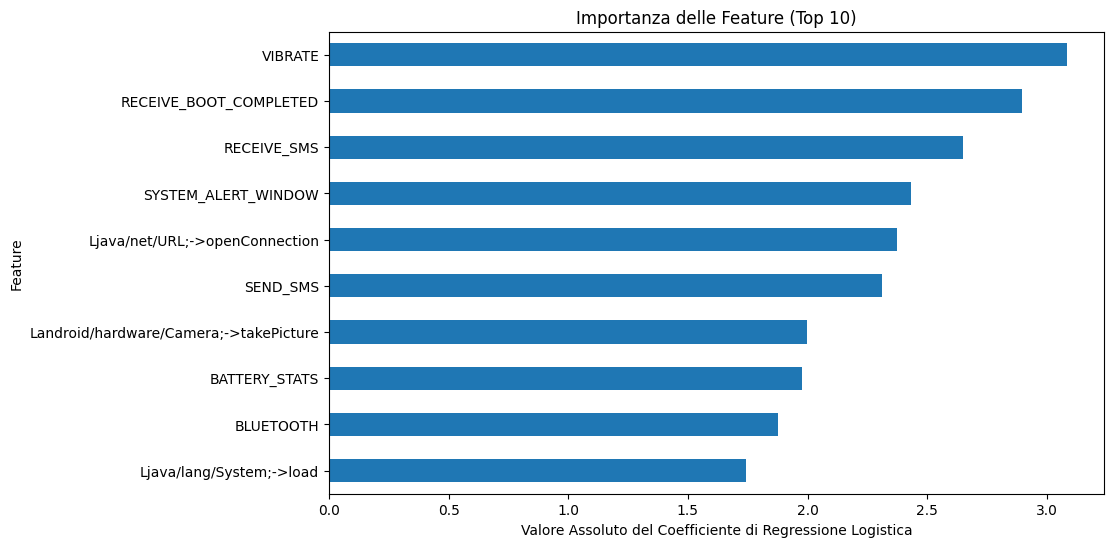

In [ ]:
# Feature importance analysis (Logistic Regression model coefficients)

# Get the model coefficients.
coefficients = model.coef_[0]

# Get feature names ensuring the order matches the coefficients.
feature_names = X_train_res.columns

# Create a Pandas Series to associate coefficients with feature names
feature_importance = pd.Series(coefficients, index=feature_names)

# Sort features in descending order based on the absolute value of coefficients to find the most important ones
sorted_feature_importance = feature_importance.abs().sort_values(ascending=False)

print("Top 10 Features by Importance (based on absolute value of Logistic Regression coefficients):")
print(sorted_feature_importance.head(10))

# Graphical visualization
plt.figure(figsize=(10, 6))
sorted_feature_importance.head(10).plot(kind='barh')
plt.title('Feature Importance (Top 10)')
plt.xlabel('Absolute Value of Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

Report di Classificazione sul Set di Test:
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96       135
         1.0       0.99      0.98      0.99       535

    accuracy                           0.98       670
   macro avg       0.97      0.98      0.97       670
weighted avg       0.98      0.98      0.98       670


Accuratezza sul Set di Test:
0.982089552238806


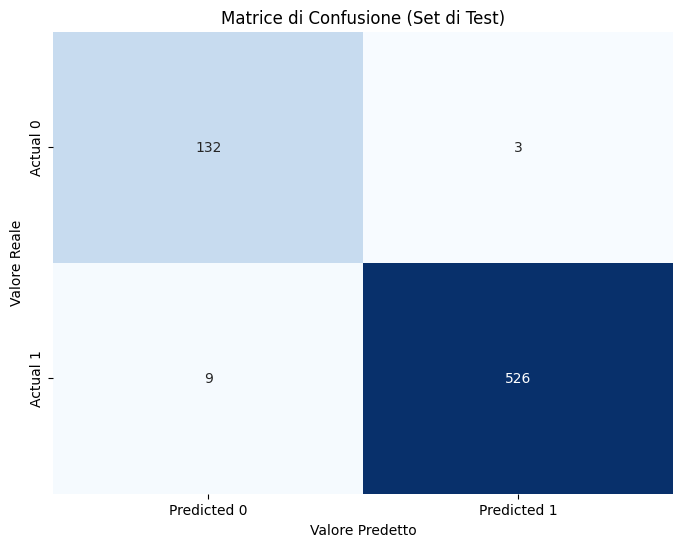


AUC sul Set di Test: 0.9970


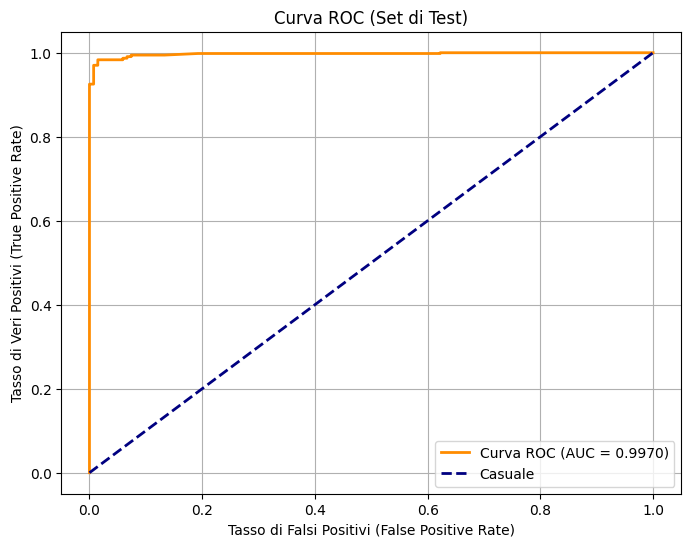

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score

# Predictions on the test set
y_pred_test = model.predict(X_test)

# Performance evaluation
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(y_test, y_pred_test)

print("\nAccuracy on Test Set:")
print(accuracy_score(y_test, y_pred_test))

# Confusion matrix plot on the test set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

# ROC curve and AUC on the Test Set
# Get prediction probabilities for the positive class on the test set
y_pred_proba_test = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba_test)

print(f"\nAUC on Test Set: {auc:.4f}")

# Display ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Verify the number of iterations (epochs) taken for convergence
# of the model trained with SMOTE
print(f"The Logistic Regression model (with SMOTE) converged in {model.n_iter_[0]} iterations.")

Il modello di Regressione Logistica (con SMOTE) è convergente in 8 iterazioni.
